In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

df = pd.read_csv(
    "../data/delhi.txt",
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=["date", "temperature"]
)

df["temperature"] = pd.to_numeric(
    df["temperature"],
    errors="coerce"
)

df.head()

,date,temperature
0,2000-01-01,285.3383
1,2000-01-02,285.8098
2,2000-01-03,285.7757
3,2000-01-04,285.4131
4,2000-01-05,285.1693


In [4]:
#kelvin to celcius
df["temperature_c"] = df["temperature"] - 273.15

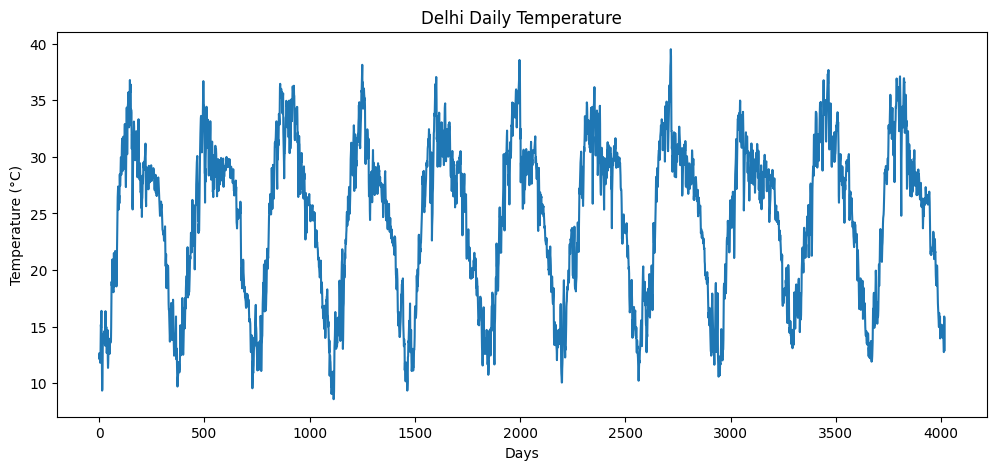

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df["temperature_c"])
plt.title("Delhi Daily Temperature")
plt.xlabel("Days")
plt.ylabel("Temperature (°C)")
plt.show()

In [6]:
#normalising the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_temp = scaler.fit_transform(df["temperature_c"].values.reshape(-1, 1))

In [7]:
sequence_length = 30

X = [] #x is input sequence and y is target outputs
y = []

for i in range(sequence_length, len(scaled_temp)):
    X.append(scaled_temp[i-sequence_length:i, 0])
    y.append(scaled_temp[i, 0])

X = np.array(X)  #converts list into numpy arrays(needed for lstm)
y = np.array(y)

In [8]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [9]:
print(X.shape)
print(y.shape)


(3988, 30, 1)
(3988,)


In [10]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(3190, 30, 1)
(798, 30, 1)


In [11]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [23]:
from keras.models import Sequential

from keras.layers import (
    LSTM,
    Dense,
    Input
)

model = Sequential()

model.add(Input(shape=(X_train.shape[1], 1)))

model.add(LSTM(
    units=100,
    return_sequences=False
))

model.add(Dense(1))

In [13]:
model.compile(
    optimizer='adam',     #how weights should be updated 
    loss='mean_squared_error'   # how prediction error is measured
)

In [14]:
model.summary()
#Parameters = 4((ninput​+nhidden​)nhidden​+nhidden​)
#ninput here is 1 and nhidden is 50

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#trainig the model
history = model.fit(      #train nn using given data this is the learning phase 
    X_train,            #trains the sliding window sequence of 30 days each with 1 feature
    y_train,                      # conatins target value 31st day
    epochs=20,              #Pass through entire training dataset 20 times
    batch_size=32,
    validation_data=(X_test, y_test)        #unseen testing data after each epoch tensorflow updates model on 
                                             #test seq and test target
                                             # loss- trainig error and val_loss is testing error on Xtest
                                             #if both dec model is learning 
                                             # if training error dec and testing error inc then overfitting may happen
)
# ( Forward pass              
#       ↓
# Prediction
#       ↓
# Compute error
     # ↓
#Backpropagation
     # ↓
#Update weights)

Epoch 1/20


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0177 - val_loss: 0.0040
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0039 - val_loss: 0.0035
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0036 - val_loss: 0.0034
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0034 - val_loss: 0.0030
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 9/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 10/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 11/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 12/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/ste

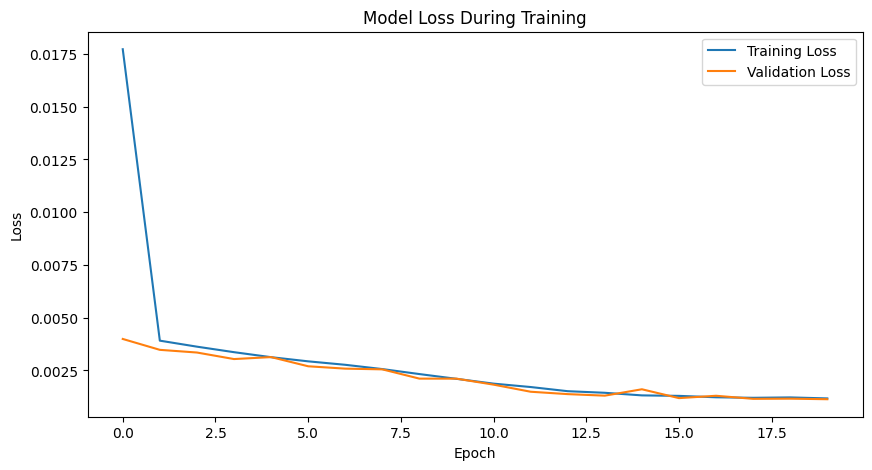

In [16]:
#loss curve plot
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('Model Loss During Training')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

In [17]:
#forecasting and evaluation
predictions = model.predict(X_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [18]:
#  inverse scaling 
predictions = scaler.inverse_transform(   #gives 2d output converst normalised to celsius
    predictions.reshape(-1,1)
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

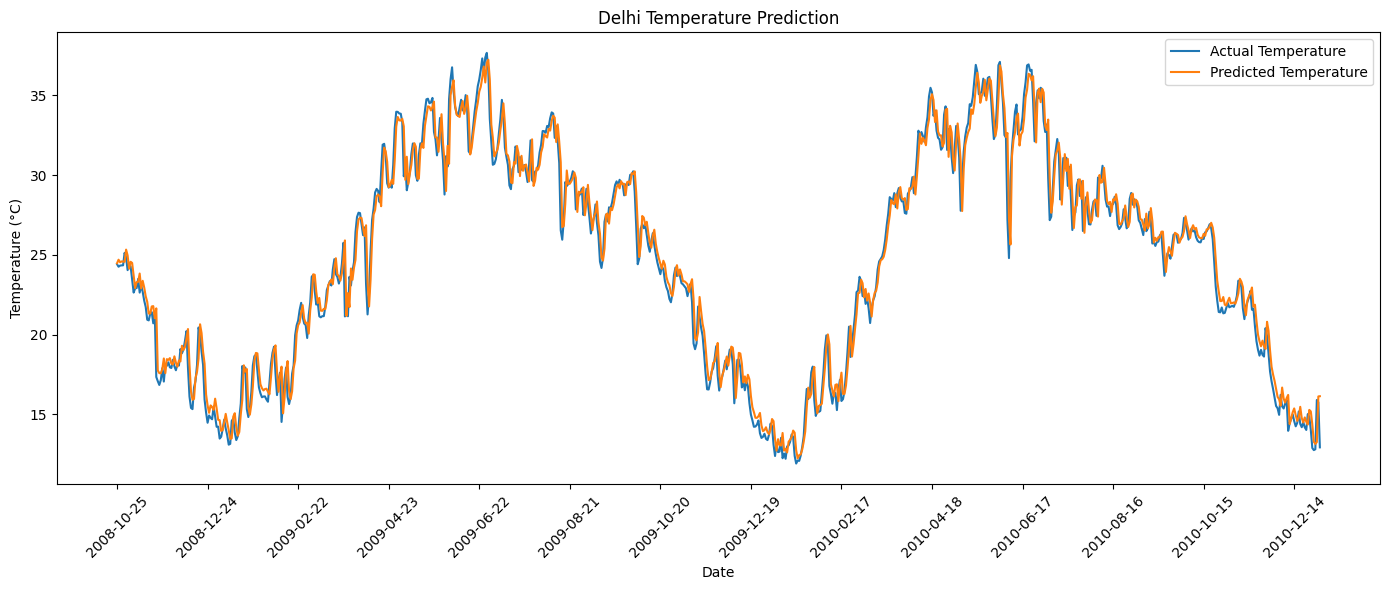

In [19]:
#forecast plot
test_dates = df['date'][-len(y_test_actual):]
plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    y_test_actual,
    label='Actual Temperature'
)

plt.plot(
    test_dates,
    predictions,
    label='Predicted Temperature'
)

plt.title('Delhi Temperature Prediction')

plt.xlabel('Date')

plt.ylabel('Temperature (°C)')

plt.legend()

plt.xticks(
    test_dates[::60],
    rotation=45
)

plt.tight_layout()

plt.show()

In [20]:
#Evaluation metrices

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

# MAE
mae = mean_absolute_error(
    y_test_actual,
    predictions
)

# R² Score
#how well predictions explain variance in actual temperatures.
                        # R² = 1  → perfect prediction
                           # R² = 0  → model no better than mean prediction
                           # R² < 0  → poor model performance 
r2 = r2_score(
    y_test_actual,
    predictions
)

# Covariance
covariance = np.cov(
    y_test_actual.flatten(),
    predictions.flatten()
)[0,1]

# Correlation
# Measures strength and direction of relationship between actual and predicted temperatures.
# Correlation ranges from -1 to +1.
correlation = np.corrcoef(
    y_test_actual.flatten(),
    predictions.flatten()
)[0,1]

print("Validation RMSE:", rmse)

print("Validation MAE:", mae)

print("Validation R²:", r2)

print("Validation Covariance:", covariance)

print("Validation Correlation:", correlation)

Validation RMSE: 1.0423777302773034
Validation MAE: 0.7773144177486992
Validation R²: 0.9761861318471159
Validation Covariance: 43.87827361200375
Validation Correlation: 0.9884856617182506


In [21]:
results_delhi = pd.DataFrame({
    "City": ["Delhi"],
    "RMSE": [rmse],
    "MAE": [mae]
})

results_delhi.to_csv(
    "../outputs/delhi_metrics.csv",
    index=False
)

In [22]:
model.save("delhi_lstm.keras")